# EDA — ecoles-elementaires.csv
Urban Data Explorer · Éducation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import json

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [3]:
# ⚠️ Change le chemin si besoin
FILE = '../brute/Score densité de services du quotidien/etablissements-scolaires-ecoles-elementaires.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
print(f'Shape : {df.shape}')
df.head()

Shape : (2237, 9)


,Type d'établissement - Année scolaire,Libellé établissement,Adresse,Arrondissement,Code INSEE,Année scolaire,Type établissement,geo_shape,geo_point_2d
0,ELEMENTAIRES (année scolaire 2022/2023),LITTRE (6) ELEM,6 RUE LITTRE,6ème Ardt,75106,2022-2023,Elémentaire,"{""coordinates"": [2.323773103790429, 48.8456432...","48.84564322059343, 2.323773103790429"
1,ELEMENTAIRES (année scolaire 2022/2023),CHAMPAGNE (17) POLY,17 CITE CHAMPAGNE,20ème Ardt,75120,2022-2023,Polyvalent,"{""coordinates"": [2.4042089809108966, 48.853330...","48.85333032620816, 2.4042089809108966"
2,ELEMENTAIRES (année scolaire 2021/2022),ALAIN-FOURNIER ( 5) ELEM,5 SQUARE ALAIN-FOURNIER,14ème Ardt,75114,2021-2022,Elémentaire,"{""coordinates"": [2.307674934788748, 48.8283242...","48.828324298488255, 2.307674934788748"
3,ELEMENTAIRES (année scolaire 2021/2022),PIERRE FONCIN (8) ELEM A,8 RUE PIERRE FONCIN,20ème Ardt,75120,2021-2022,Elémentaire,"{""coordinates"": [2.409709173567288, 48.8713591...","48.87135911993382, 2.409709173567288"
4,ELEMENTAIRES (année scolaire 2021/2022),CHARENTON (315) ELEM,315 RUE DE CHARENTON,12ème Ardt,75112,2021-2022,Elémentaire,"{""coordinates"": [2.3951603278960523, 48.833631...","48.833631434636594, 2.3951603278960523"


## 2. Extraction des coordonnées (geo_shape GeoJSON)

In [6]:
# Le champ geo_shape contient du GeoJSON : on en extrait latitude / longitude
def parse_geometry(val):
    try:
        g = json.loads(val)
        lon, lat = g['coordinates']
        return pd.Series({'longitude': lon, 'latitude': lat})
    except Exception:
        return pd.Series({'longitude': np.nan, 'latitude': np.nan})

df[['longitude', 'latitude']] = df['geo_shape'].apply(parse_geometry)

# Coherence avec geo_point_2d (format 'lat, lon')
geo = df['geo_point_2d'].str.split(',', expand=True).astype(float)
ecart = (geo[0] - df['latitude']).abs().max()
print(f'Ecart max geo_shape vs geo_point_2d : {ecart:.2e}')
df[['Libellé établissement', 'latitude', 'longitude']].head()

Ecart max geo_shape vs geo_point_2d : 0.00e+00


,Libellé établissement,latitude,longitude
0,LITTRE (6) ELEM,48.845643,2.323773
1,CHAMPAGNE (17) POLY,48.853330,2.404209
2,ALAIN-FOURNIER ( 5) ELEM,48.828324,2.307675
3,PIERRE FONCIN (8) ELEM A,48.871359,2.409709
4,CHARENTON (315) ELEM,48.833631,2.395160


## 3. Infos générales

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Type d'établissement - Année scolaire  2237 non-null   object 
 1   Libellé établissement                  2237 non-null   object 
 2   Adresse                                2237 non-null   object 
 3   Arrondissement                         2237 non-null   object 
 4   Code INSEE                             2237 non-null   int64  
 5   Année scolaire                         2166 non-null   object 
 6   Type établissement                     2237 non-null   object 
 7   geo_shape                              2237 non-null   object 
 8   geo_point_2d                           2237 non-null   object 
 9   longitude                              2237 non-null   float64
 10  latitude                               2237 non-null   float64
dtypes: f

In [8]:
df.describe(include='all')

,Type d'établissement - Année scolaire,Libellé établissement,Adresse,Arrondissement,Code INSEE,Année scolaire,Type établissement,geo_shape,geo_point_2d,longitude,latitude
count,2237,2237,2237,2237,2237.000000,2166,2237,2237,2237,2237.000000,2237.000000
unique,6,427,658,20,NaN,6,2,362,362,NaN,NaN
top,ELEMENTAIRES (année scolaire 2022/2023),ST BENOIT (12) POLY,12 RUE SAINT BENOIT,20ème Ardt,NaN,2023-2024,Elémentaire,"{""coordinates"": [2.351305571901135, 48.8222309...","48.8222309853145, 2.351305571901135",NaN,NaN
freq,426,12,12,261,NaN,363,1670,13,13,NaN,NaN
mean,NaN,NaN,NaN,NaN,75114.013411,NaN,NaN,NaN,NaN,2.351316,48.862319
std,NaN,NaN,NaN,NaN,4.985919,NaN,NaN,NaN,NaN,0.036868,0.022244
min,NaN,NaN,NaN,NaN,75101.000000,NaN,NaN,NaN,NaN,2.254649,48.820889
25%,NaN,NaN,NaN,NaN,75111.000000,NaN,NaN,NaN,NaN,2.325549,48.843591
50%,NaN,NaN,NaN,NaN,75115.000000,NaN,NaN,NaN,NaN,2.355623,48.864589
75%,NaN,NaN,NaN,NaN,75118.000000,NaN,NaN,NaN,NaN,2.379668,48.882292


## 4. Valeurs manquantes

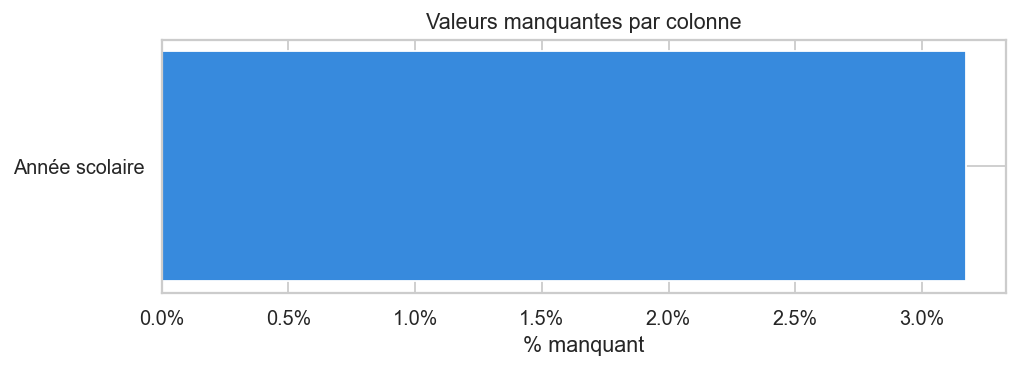

,% manquant
Année scolaire,3.173894


In [9]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('✅ Aucune valeur manquante')
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    ax.barh(missing.index, missing.values, color='#378ADD')
    ax.set_xlabel('% manquant')
    ax.set_title('Valeurs manquantes par colonne')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()
    display(missing.rename('% manquant').to_frame())

## 5. Doublons

In [10]:
n_dup = df.duplicated().sum()
print(f'Doublons exacts          : {n_dup} ({n_dup/len(df)*100:.2f}%)')
n_dup_geo = df.duplicated(subset=['latitude','longitude']).sum()
print(f'Doublons sur coordonnees : {n_dup_geo} ({n_dup_geo/len(df)*100:.2f}%)')
print('\nNote : un meme etablissement apparait sur plusieurs annees scolaires,')
print('       d\'ou de nombreux doublons de coordonnees (a dedoublonner en silver).')
if n_dup_geo > 0:
    display(df[df.duplicated(subset=['latitude','longitude'], keep=False)]
            .sort_values(['latitude','longitude'])[['Libellé établissement','Année scolaire','latitude','longitude']].head(10))

Doublons exacts          : 0 (0.00%)
Doublons sur coordonnees : 1875 (83.82%)

Note : un meme etablissement apparait sur plusieurs annees scolaires,
       d'ou de nombreux doublons de coordonnees (a dedoublonner en silver).


,Libellé établissement,Année scolaire,latitude,longitude
196,EMILE LEVASSOR (3) ELEM,2024-2025,48.820889,2.369043
337,EMILE LEVASSOR (3) ELEM,2026-2027,48.820889,2.369043
537,EMILE LEVASSOR (3) ELEM,2025-2026,48.820889,2.369043
831,EMILE LEVASSOR (3) ELEM,2023-2024,48.820889,2.369043
1718,EMILE LEVASSOR (3) ELEM,2022-2023,48.820889,2.369043
1923,EMILE LEVASSOR (3) ELEM,2021-2022,48.820889,2.369043
88,PORTE D'IVRY (51) ELEM,2026-2027,48.821128,2.369608
622,PORTE D'IVRY (51) ELEM,2023-2024,48.821128,2.369608
915,PORTE D'IVRY (51) ELEM,2022-2023,48.821128,2.369608
1534,PORTE D'IVRY (51) ELEM,2025-2026,48.821128,2.369608


## 6. Détection des colonnes clés

In [11]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'libelle'        : find_col(df, 'libellé', 'libelle', 'nom', 'name'),
    'type'           : find_col(df, 'type établissement', 'type etablissement'),
    'arrondissement' : find_col(df, 'arrondissement'),
    'annee'          : find_col(df, 'année scolaire', 'annee scolaire'),
    'latitude'       : find_col(df, 'latitude', 'lat'),
    'longitude'      : find_col(df, 'longitude', 'lon', 'lng'),
}
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'{status}  {k:14s} → {v}')

✅  libelle        → Libellé établissement
✅  type           → Type établissement
✅  arrondissement → Arrondissement
✅  annee          → Type d'établissement - Année scolaire
✅  latitude       → latitude
✅  longitude      → longitude


## 7. Répartition par type d'établissement

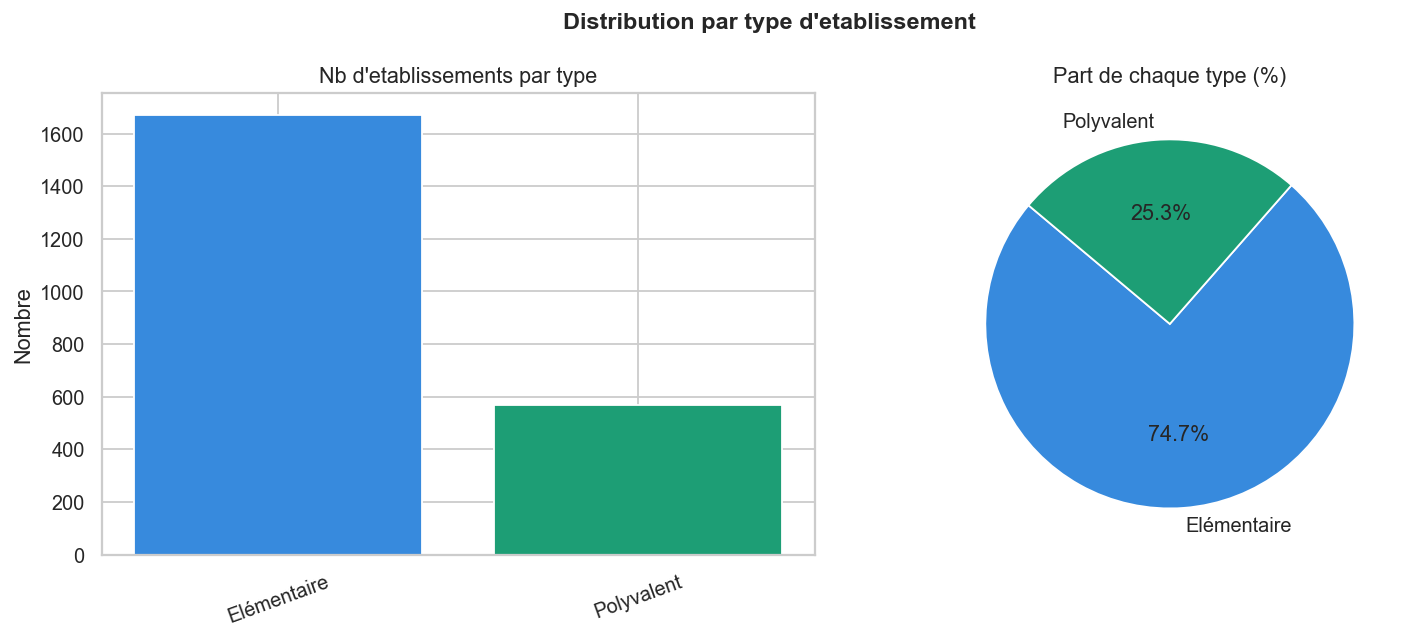

,type,count
0,Elémentaire,1670
1,Polyvalent,567


In [12]:
type_col = col_map['type']
if type_col:
    vc = df[type_col].fillna('(vide)').value_counts().reset_index()
    vc.columns = ['type', 'count']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    colors = ['#378ADD','#1D9E75','#D85A30','#BA7517','#888780','#534AB7','#D4537E']
    ax1.bar(vc['type'].astype(str), vc['count'], color=colors[:len(vc)])
    ax1.set_title('Nb d\'etablissements par type')
    ax1.set_ylabel('Nombre')
    ax1.tick_params(axis='x', rotation=20)
    ax2.pie(vc['count'], labels=vc['type'].astype(str), autopct='%1.1f%%',
            colors=colors[:len(vc)], startangle=140)
    ax2.set_title('Part de chaque type (%)')
    plt.suptitle('Distribution par type d\'etablissement', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    display(vc)
else:
    print('❌ Colonne type non trouvee')

## 8. Répartition par arrondissement

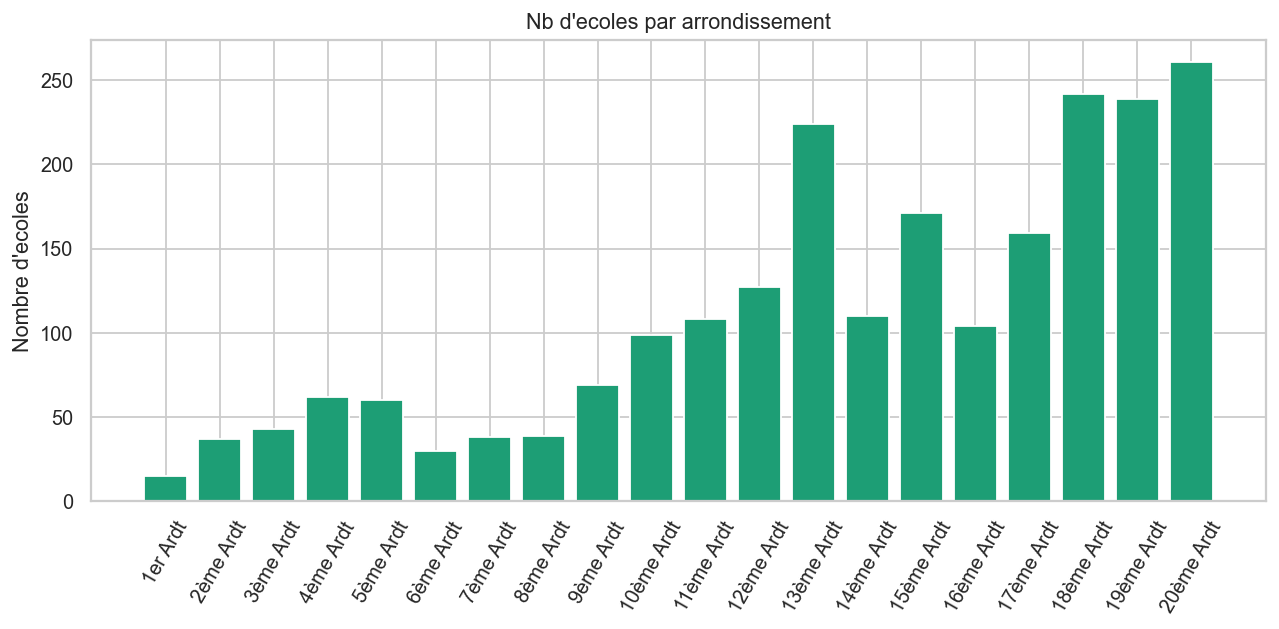

In [13]:
arr_col = col_map['arrondissement']
if arr_col:
    # tri par numero d'arrondissement extrait du libelle (ex: '6ème Ardt')
    vc = df[arr_col].value_counts()
    vc = vc.reindex(sorted(vc.index, key=lambda x: int(''.join(filter(str.isdigit, str(x))) or 0)))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(vc.index.astype(str), vc.values, color='#1D9E75')
    ax.set_title('Nb d\'ecoles par arrondissement')
    ax.set_ylabel('Nombre d\'ecoles')
    ax.tick_params(axis='x', rotation=60)
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonne arrondissement non trouvee')

## 9. Distribution géographique

Points dans Paris intra-muros (approx) : 2,237
Points en IDF                          : 2,237
Hors IDF                               : 0


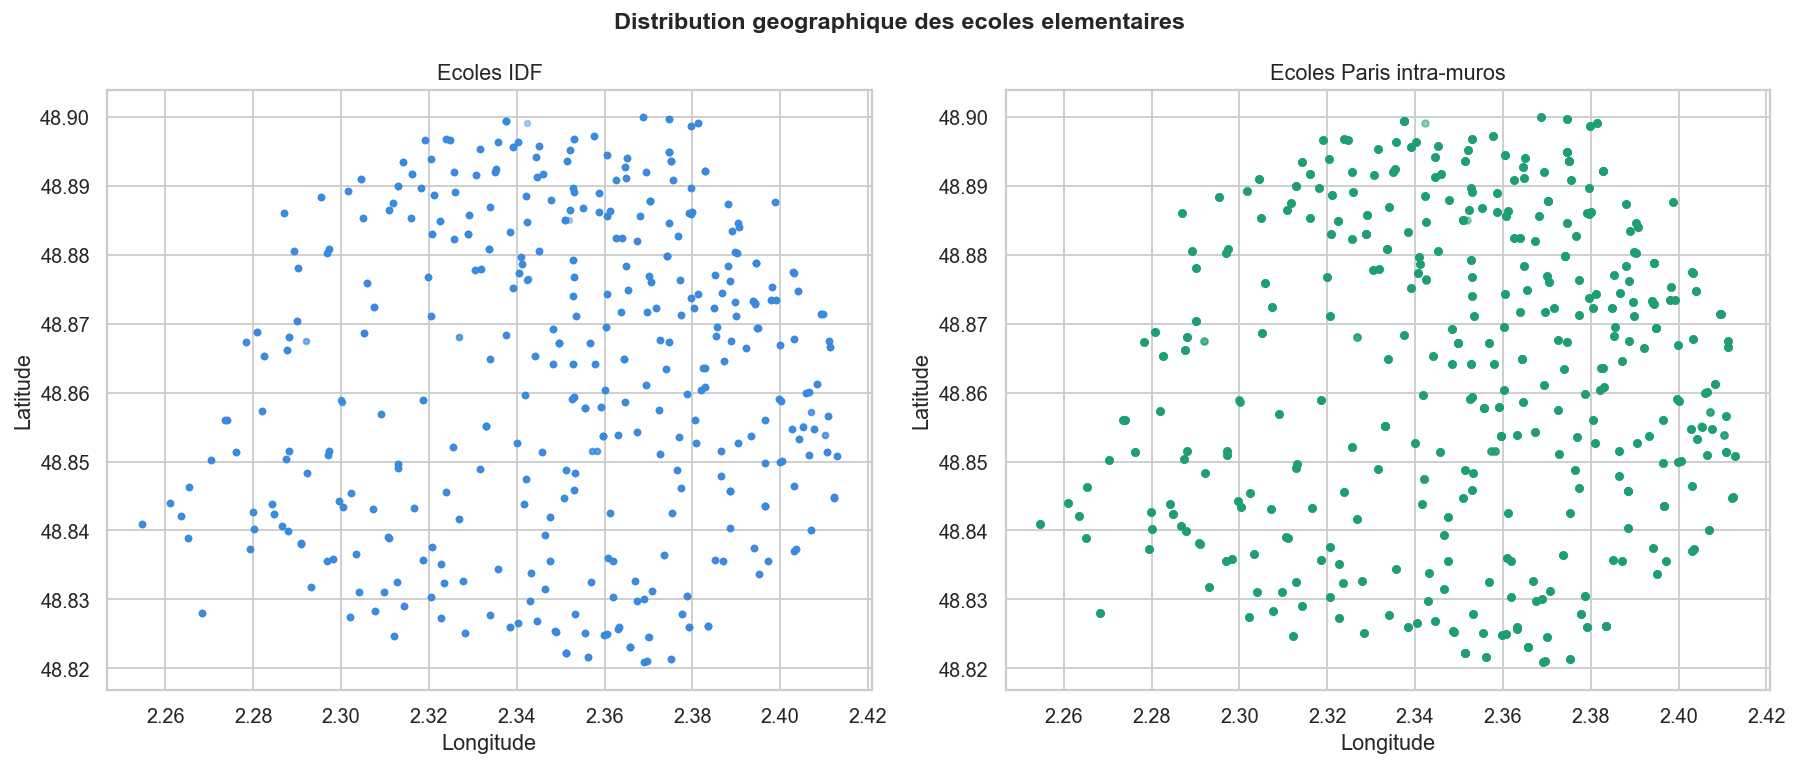

In [14]:
lat_col, lon_col = col_map['latitude'], col_map['longitude']
if lat_col and lon_col:
    geo = df[[lat_col, lon_col]].dropna()
    paris = geo[(geo[lat_col].between(48.75, 49.05)) & (geo[lon_col].between(2.1, 2.55))]
    idf   = geo[(geo[lat_col].between(48.0, 49.4))  & (geo[lon_col].between(1.4, 3.6))]

    print(f'Points dans Paris intra-muros (approx) : {len(paris):,}')
    print(f'Points en IDF                          : {len(idf):,}')
    print(f'Hors IDF                               : {len(geo) - len(idf):,}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(idf[lon_col], idf[lat_col], s=10, alpha=0.4, color='#378ADD')
    axes[0].set_title('Ecoles IDF')
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
    axes[1].scatter(paris[lon_col], paris[lat_col], s=14, alpha=0.5, color='#1D9E75')
    axes[1].set_title('Ecoles Paris intra-muros')
    axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
    plt.suptitle('Distribution geographique des ecoles elementaires', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonnes lat/lon non trouvees')

## 11. Résumé final

In [15]:
print('=' * 50)
print('RESUME EDA — ecoles-elementaires.csv')
print('=' * 50)
print(f'  Lignes          : {len(df):,}')
print(f'  Colonnes        : {len(df.columns)}')
print(f'  Doublons exacts : {df.duplicated().sum()}')
print(f'  Doublons coords : {df.duplicated(subset=["latitude","longitude"]).sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN   : {missing_count}')
if col_map['type']:
    print(f'  Types           : {df[col_map["type"]].nunique()} ({", ".join(map(str, df[col_map["type"]].unique()))})')
if col_map['arrondissement']:
    print(f'  Arrondissements : {df[col_map["arrondissement"]].nunique()}')
if lat_col and lon_col:
    print(f'  Lat range       : {df[lat_col].min():.4f} → {df[lat_col].max():.4f}')
    print(f'  Lon range       : {df[lon_col].min():.4f} → {df[lon_col].max():.4f}')
print('=' * 50)

RESUME EDA — ecoles-elementaires.csv
  Lignes          : 2,237
  Colonnes        : 11
  Doublons exacts : 0
  Doublons coords : 1875
  Cols avec NaN   : 1
  Types           : 2 (Elémentaire, Polyvalent)
  Arrondissements : 20
  Lat range       : 48.8209 → 48.8999
  Lon range       : 2.2546 → 2.4129
